[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AyhamAlsuwi/ML-projects/blob/main/USA-used-cars-price-prediction-model/cars%20price%20prediction.ipynb)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)

In [5]:
pd.set_option('display.max_rows', 200)

In [7]:
df = pd.read_csv('car_prices.csv')

In [346]:
df.shape

(558837, 16)

In [8]:
df

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [11]:
df.head(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
5,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,Tue Dec 30 2014 12:00:00 GMT-0800 (PST)
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,Tue Dec 16 2014 13:00:00 GMT-0800 (PST)
8,2014,Audi,A4,2.0T Premium Plus quattro,Sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
9,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,red,black,d/m auto sales inc,26300.0,17500.0,Tue Jan 20 2015 04:00:00 GMT-0800 (PST)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [14]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [17]:
df.describe(include='O')

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,548536,548438,548186,545642,493485,558833,558837,558088,558088,558837,558825
unique,96,973,1963,87,4,550297,64,46,17,14263,3766
top,Ford,Altima,Base,Sedan,automatic,automatic,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,93554,19349,55817,199437,475915,22,82945,110970,244329,19693,5334


In [18]:
df.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

## dropping some columns that can cause overfitting or data leakage or not effective

In [22]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [24]:
df_modified = df.drop(columns=['vin', 'mmr', 'seller','make'])

In [26]:
df_modified

,year,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice,saledate
0,2015,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,K900,Luxury,Sedan,NaN,in,45.0,18255.0,silver,black,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,2500,Power Wagon,Crew Cab,automatic,wa,5.0,54393.0,white,black,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,X5,xDrive35d,SUV,automatic,ca,48.0,50561.0,black,black,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Altima,2.5 S,sedan,automatic,ga,38.0,16658.0,white,black,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


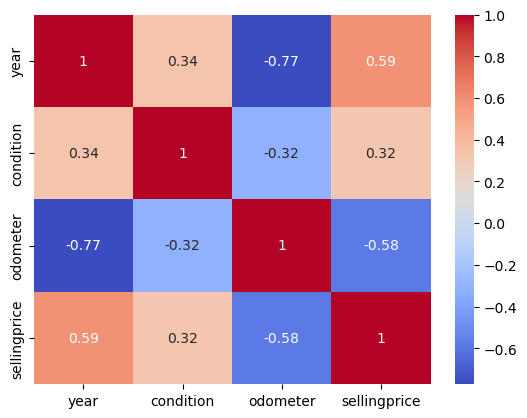

In [28]:
sns.heatmap(df_modified.corr(numeric_only=True), annot=True , cmap='coolwarm');

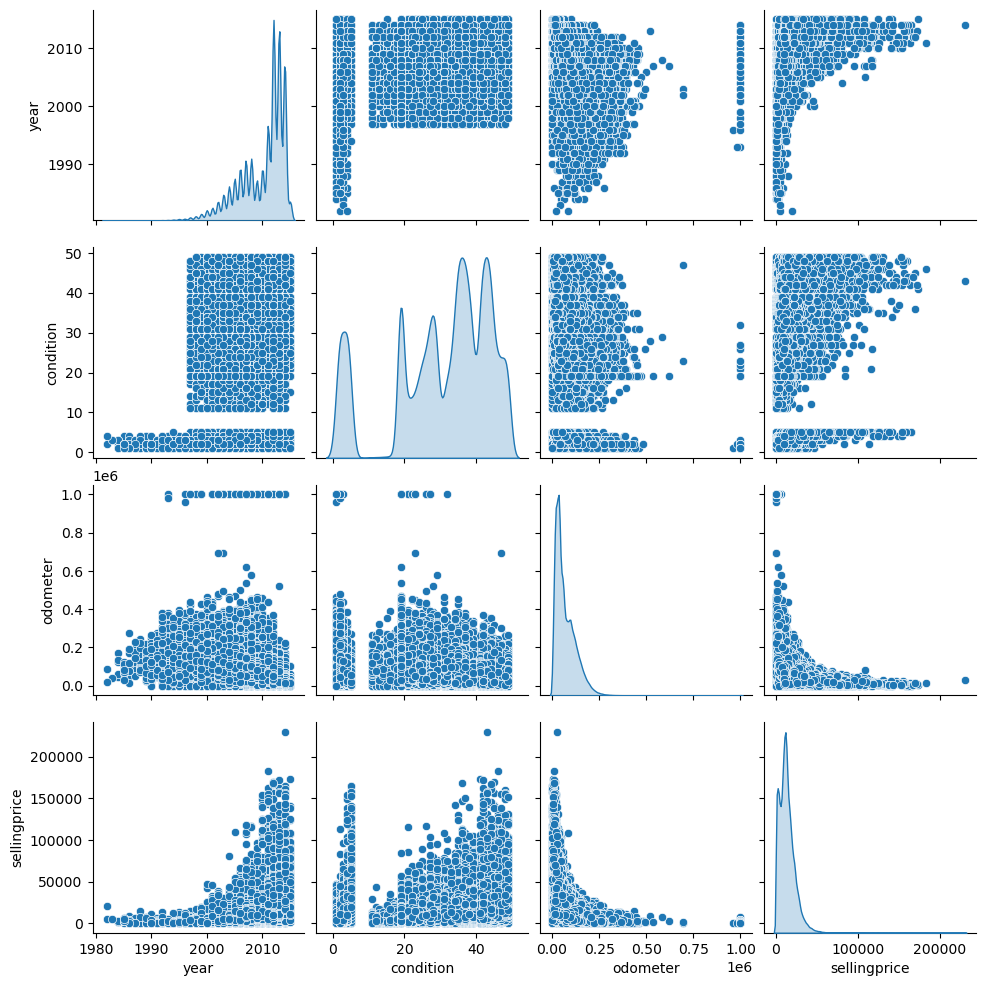

In [29]:
sns.pairplot(df_modified,diag_kind='kde');

## stratified splitting

In [32]:
## missing values in target must drop
df_modified['sellingprice'].isna().sum()

12

In [43]:
df_modified = df_modified.dropna(subset=['sellingprice'])
df_modified['sellingprice'].isna().sum()

0

In [45]:
## dropping duplicates if exists
df_modified.duplicated().sum()

0

In [47]:
bins = [1980 , 1990 , 1995, 2000, 2005, 2010, np.inf]
labels =[1, 2, 3, 4, 5, 6]
df_modified['binned_year'] = pd.cut(df_modified['year'], bins=bins, labels=labels)

In [49]:
inputs = df_modified.drop(columns=['sellingprice'])
outputs = df_modified['sellingprice']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(inputs,outputs, test_size=0.1, stratify=df_modified['binned_year'], random_state=42)

In [53]:
X_train = X_train.drop(columns=['binned_year'])
X_test = X_test.drop(columns=['binned_year'])

In [55]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((502942, 11), (55883, 11), (502942,), (55883,))

## data cleaning

In [58]:
X_train.isna().sum()

year                0
model            9338
trim             9576
body            11885
transmission    58758
state               0
condition       10622
odometer           79
color             698
interior          698
saledate            0
dtype: int64

In [60]:
from sklearn.experimental import enable_iterative_imputer  # Required for IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import HistGradientBoostingRegressor, IsolationForest

# 1. Initialize the Imputer using HistGradientBoosting
imputer = IterativeImputer(
    estimator=HistGradientBoostingRegressor(),
      random_state=42
)

X_train_imputed = imputer.fit_transform(X_train.select_dtypes(include=np.number))

# 3. Run Isolation Forest on the imputed data
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_train_imputed)


C:\Users\ASUS\Anaconda3.7\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


IsolationForest(contamination=0.01, random_state=42)

In [62]:
X_train['anomaly'] = iso.predict(X_train_imputed)

In [63]:
X_train[X_train['anomaly'] == -1]

,year,model,trim,body,transmission,state,condition,odometer,color,interior,saledate,anomaly
166303,1996,C-Class,C280,Sedan,automatic,oh,1.0,140718.0,blue,tan,Thu Jan 22 2015 01:00:00 GMT-0800 (PST),-1
367686,2005,6 Series,645Ci,Convertible,automatic,il,1.0,999999.0,silver,gray,Tue Mar 03 2015 05:00:00 GMT-0800 (PST),-1
313035,2001,Mustang,Deluxe,Convertible,NaN,ca,1.0,220744.0,silver,black,Wed Feb 18 2015 03:00:00 GMT-0800 (PST),-1
166354,1992,Camry,XLE V6,Sedan,NaN,ca,3.0,164092.0,white,blue,Fri Jan 16 2015 07:00:00 GMT-0800 (PST),-1
261183,1996,Escort,LX,Wagon,automatic,fl,2.0,269338.0,blue,blue,Thu Feb 26 2015 05:00:00 GMT-0800 (PST),-1
...,...,...,...,...,...,...,...,...,...,...,...,...
398514,1996,NaN,NaN,NaN,automatic,nc,2.0,198218.0,red,red,Tue Mar 10 2015 01:30:00 GMT-0700 (PDT),-1
234553,1994,NaN,NaN,NaN,automatic,fl,2.0,149689.0,white,blue,Tue Feb 03 2015 10:00:00 GMT-0800 (PST),-1
187474,1999,4Runner,SR5,SUV,NaN,nj,42.0,226256.0,green,beige,Wed Jan 28 2015 02:00:00 GMT-0800 (PST),-1
329588,2000,NaN,NaN,NaN,manual,pa,48.0,13093.0,red,black,Fri Feb 20 2015 01:15:00 GMT-0800 (PST),-1


In [64]:
X_train = X_train.drop(columns=['anomaly'])

## transformers

In [69]:
import importlib
import custom_transformers

# Force the kernel to read the file again
importlib.reload(custom_transformers)

<module 'custom_transformers' from 'C:\\Users\\ASUS\\Desktop\\ML\\USA cars prices\\custom_transformers.py'>

In [71]:
from sklearn.preprocessing import FunctionTransformer
    
log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

In [73]:
from custom_transformers import NumericStringToNaN
nn = NumericStringToNaN()

In [75]:
from custom_transformers import LowerCase
lc = LowerCase()

In [77]:
from custom_transformers import DashToNaN
dn = DashToNaN()


In [79]:
from custom_transformers import YearExtractor
ye = YearExtractor()


In [81]:
from custom_transformers import KeepAutoManual
km = KeepAutoManual()

In [83]:
from custom_transformers import LongStringToNaN
ls = LongStringToNaN()

In [85]:
from custom_transformers import FrequencyEncoder


## Pipelines

In [88]:
X_train.isna().sum()

year                0
model            9338
trim             9576
body            11885
transmission    58758
state               0
condition       10622
odometer           79
color             698
interior          698
saledate            0
dtype: int64

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder,StandardScaler

In [92]:
num_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='median')),
    ('transformer' , FunctionTransformer(np.log1p, feature_names_out='one-to-one' )),
    ('scaler' , StandardScaler())
])
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('transformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [94]:
year_built_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('transformer' , FunctionTransformer(np.log1p, feature_names_out='one-to-one' )),
    ('scaler' , StandardScaler())
])
year_built_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('transformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [96]:
X_train.describe(include='O')

,model,trim,body,transmission,state,color,interior,saledate
count,493604,493366,491057,444184,502942,502244,502244,502942
unique,966,1945,87,4,61,43,17,3699
top,Altima,Base,Sedan,automatic,fl,black,black,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,17402,50174,179524,428405,74609,99979,219791,4830


In [97]:
trim_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('transformer2' , LowerCase()),
    ('encoder' , FrequencyEncoder())
])
trim_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('transformer2', LowerCase()),
                ('encoder', FrequencyEncoder())])

In [98]:
model_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('transformer2' , LowerCase()),
    ('encoder' , TargetEncoder(target_type='continuous' , cv=5))
])
model_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('transformer2', LowerCase()),
                ('encoder', TargetEncoder(target_type='continuous'))])

In [99]:
body_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('transformer2' , LowerCase()),
    ('encoder' , OneHotEncoder(handle_unknown='ignore' , sparse_output=False))
])
body_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('transformer2', LowerCase()),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [103]:
state_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('transformer2' , LongStringToNaN()),
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('transformer3' , LowerCase()),
   
    ('encoder' , OneHotEncoder(handle_unknown='ignore' , sparse_output=False))
])
state_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('transformer2', LongStringToNaN()),
                ('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('transformer3', LowerCase()),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [106]:
colors_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('transformer2' , NumericStringToNaN()),
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('transformer3' , LowerCase()),
    ('scaler' , FrequencyEncoder())
])
colors_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('transformer2', NumericStringToNaN()),
                ('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('transformer3', LowerCase()), ('scaler', FrequencyEncoder())])

In [108]:
transmission_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('transformer2' , KeepAutoManual()),
    ('transformer3' , LowerCase()),
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder' , OneHotEncoder(handle_unknown='ignore' , sparse_output=False))
])
transmission_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('transformer2', KeepAutoManual()),
                ('transformer3', LowerCase()),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [110]:
date_sold_pipeline =  Pipeline(steps=[
    ('transformer1' , DashToNaN()),
    ('transformer2' , YearExtractor()),
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder' ,StandardScaler())
])
date_sold_pipeline

Pipeline(steps=[('transformer1', DashToNaN()),
                ('transformer2', YearExtractor()),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', StandardScaler())])

In [112]:
X_train.columns

Index(['year', 'model', 'trim', 'body', 'transmission', 'state', 'condition',
       'odometer', 'color', 'interior', 'saledate'],
      dtype='object')

In [114]:
num_features = ['condition','odometer']

In [116]:
from sklearn.compose import ColumnTransformer

In [118]:
preprocessing = ColumnTransformer(transformers=[
    ('date_sold' , date_sold_pipeline, ['saledate']),
    ('transmission_encoded' , transmission_pipeline , ['transmission']),
    ('colores_encoded' , colors_pipeline , ['color', 'interior']),
    ('state_encoded' , state_pipeline , ['state']),
    ('body_encoded' , body_pipeline , ['body']),
    ('model_encoded' , model_pipeline , ['model']),
    ('trim_encoded' , trim_pipeline , ['trim']),
    ('year_built' , year_built_pipeline , ['year']),
    ('logged' , num_pipeline , num_features)])

preprocessing

ColumnTransformer(transformers=[('date_sold',
                                 Pipeline(steps=[('transformer1', DashToNaN()),
                                                 ('transformer2',
                                                  YearExtractor()),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  StandardScaler())]),
                                 ['saledate']),
                                ('transmission_encoded',
                                 Pipeline(steps=[('transformer1', DashToNaN()),
                                                 ('transformer2',
                                                  KeepAutoManual()),
                                                 ('transformer3', LowerCase()...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['year']),
                                ('logged',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['condition', 'odometer'])])

In [120]:
preprocessing.set_output(transform="pandas")

ColumnTransformer(transformers=[('date_sold',
                                 Pipeline(steps=[('transformer1', DashToNaN()),
                                                 ('transformer2',
                                                  YearExtractor()),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  StandardScaler())]),
                                 ['saledate']),
                                ('transmission_encoded',
                                 Pipeline(steps=[('transformer1', DashToNaN()),
                                                 ('transformer2',
                                                  KeepAutoManual()),
                                                 ('transformer3', LowerCase()...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['year']),
                                ('logged',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['condition', 'odometer'])])

In [122]:
ex = preprocessing.fit_transform(X_train , Y_train)

In [124]:
ex.shape

(502942, 96)

In [126]:
preprocessing.get_feature_names_out()

array(['date_sold__saledate',
       'transmission_encoded__transmission_automatic',
       'transmission_encoded__transmission_manual',
       'colores_encoded__color', 'colores_encoded__interior',
       'state_encoded__state_ab', 'state_encoded__state_al',
       'state_encoded__state_az', 'state_encoded__state_ca',
       'state_encoded__state_co', 'state_encoded__state_fl',
       'state_encoded__state_ga', 'state_encoded__state_hi',
       'state_encoded__state_il', 'state_encoded__state_in',
       'state_encoded__state_la', 'state_encoded__state_ma',
       'state_encoded__state_md', 'state_encoded__state_mi',
       'state_encoded__state_mn', 'state_encoded__state_mo',
       'state_encoded__state_ms', 'state_encoded__state_nc',
       'state_encoded__state_ne', 'state_encoded__state_nj',
       'state_encoded__state_nm', 'state_encoded__state_ns',
       'state_encoded__state_nv', 'state_encoded__state_ny',
       'state_encoded__state_oh', 'state_encoded__state_ok',
       '

In [128]:
preprocessing.get_params()

{'force_int_remainder_cols': True,
 'n_jobs': None,
 'remainder': 'drop',
 'sparse_threshold': 0.3,
 'transformer_weights': None,
 'transformers': [('date_sold',
   Pipeline(steps=[('transformer1', DashToNaN()),
                   ('transformer2', YearExtractor()),
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', StandardScaler())]),
   ['saledate']),
  ('transmission_encoded',
   Pipeline(steps=[('transformer1', DashToNaN()),
                   ('transformer2', KeepAutoManual()),
                   ('transformer3', LowerCase()),
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder',
                    OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
   ['transmission']),
  ('colores_encoded',
   Pipeline(steps=[('transformer1', DashToNaN()),
                   ('transformer2', NumericStringToNaN()),
                   ('imputer',
                    SimpleImputer(fil

## model selection

### linear regression

In [136]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', LinearRegression())
])

In [138]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2':'r2'
}

cv_results_lin = cross_validate(
    linear_model, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=14,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 out of   4 | elapsed:   16.8s finished


In [140]:
-cv_results_lin['train_rmse'].mean(), -cv_results_lin['test_rmse'].mean()

(5176.4174861815145, 5211.746781299341)

In [142]:
-cv_results_lin['train_mape'].mean(), -cv_results_lin['test_mape'].mean()

(0.9356764010453332, 0.9358300868721079)

In [144]:
-cv_results_lin['train_mae'].mean(), -cv_results_lin['test_mae'].mean()

(3526.4448954061972, 3532.858262487519)

In [148]:
cv_results_lin['train_r2'].mean(), cv_results_lin['test_r2'].mean()

(0.7179402258889289, 0.7140732290381115)

### Random forest

In [151]:
from sklearn.ensemble import RandomForestRegressor

randf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(random_state=42))
])


In [153]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2':'r2'
}

cv_results_randf = cross_validate(
    randf_model, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=15,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   4 out of   4 | elapsed: 12.5min finished


In [155]:
-cv_results_randf['train_rmse'].mean(), -cv_results_randf['test_rmse'].mean()

(1404.8104144757156, 2436.0373153633827)

In [157]:
-cv_results_randf['train_mape'].mean(), -cv_results_randf['test_mape'].mean()

(0.12291912655088126, 0.25973708085482217)

In [159]:
-cv_results_randf['train_mae'].mean(), -cv_results_randf['test_mae'].mean()

(677.3496226081027, 1351.954158766891)

In [161]:
cv_results_randf['train_r2'].mean(), cv_results_randf['test_r2'].mean()

(0.9788540368266369, 0.9374610623591777)

### XGBoost

In [164]:
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('xgb_reg' , XGBRegressor(random_state = 42))
])

In [166]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results_xgb = cross_validate(
    xgb_model, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=15,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   4 out of   4 | elapsed:   26.2s finished


In [174]:
-cv_results_xgb['train_rmse'].mean(), -cv_results_xgb['test_rmse'].mean()

(2779.2044522455253, 2961.9629237104414)

In [168]:
-cv_results_xgb['train_mae'].mean(), -cv_results_xgb['test_mae'].mean()

(1695.2466124346256, 1737.9302938323488)

In [170]:
-cv_results_xgb['train_mape'].mean(), -cv_results_xgb['test_mape'].mean()

(0.27637090943567677, 0.29230572574029734)

In [172]:
cv_results_xgb['train_r2'].mean(), cv_results_xgb['test_r2'].mean()

(0.9186911898044245, 0.9076332292669068)

In [178]:
xgb_model.fit(X_train , Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('date_sold',
                                                  Pipeline(steps=[('transformer1',
                                                                   DashToNaN()),
                                                                  ('transformer2',
                                                                   YearExtractor()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   StandardScaler())]),
                                                  ['saledate']),
                                                 ('transmission_encoded',
                                                  Pipeline(steps=[('transformer1',
                                                                   DashToNaN()),
                                                                  ('transformer2',
                                                                   KeepAutoManu...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [180]:
sorted(zip(xgb_model['xgb_reg'].feature_importances_ , xgb_model['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.15025671, 'logged__odometer'),
 (0.12852098, 'model_encoded__model'),
 (0.08084199, 'year_built__year'),
 (0.07971307, 'body_encoded__body_supercrew'),
 (0.045160506, 'body_encoded__body_crew cab'),
 (0.04468435, 'body_encoded__body_regular cab'),
 (0.028650803, 'body_encoded__body_suv'),
 (0.022852024, 'body_encoded__body_g coupe'),
 (0.02275154, 'body_encoded__body_hatchback'),
 (0.021783976, 'state_encoded__state_on'),
 (0.020700816, 'logged__condition'),
 (0.020053184, 'body_encoded__body_convertible'),
 (0.019779187, 'body_encoded__body_unknown'),
 (0.018693477, 'body_encoded__body_minivan'),
 (0.018643908, 'body_encoded__body_e-series van'),
 (0.017538518, 'state_encoded__state_ca'),
 (0.015730616, 'trim_encoded__trim'),
 (0.014420516, 'body_encoded__body_crewmax cab'),
 (0.013835037, 'body_encoded__body_wagon'),
 (0.013047555, 'body_encoded__body_van'),
 (0.012810729, 'body_encoded__body_genesis coupe'),
 (0.012379424, 'body_encoded__body_coupe'),
 (0.012210335, 'body_encode

## I chose XGBoot, it have the best scores without tuning

### V2

In [188]:
from xgboost import XGBRegressor

xgb_model_v2 = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('xgb_reg' , XGBRegressor(random_state = 42))
])

In [200]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'xgb_reg__n_estimators': randint(300,800),
    'xgb_reg__learning_rate': [0.01, 0.05, 0.09,0.1],
    'xgb_reg__max_depth':  randint(5,20),
    'xgb_reg__colsample_bytree': [0.7, 0.8, 0.9,1.0],
    'xgb_reg__min_child_weight': randint(4,30),
}



xgb_search = RandomizedSearchCV(
    xgb_model_v2, 
    param_distributions=param_dist,
    n_iter=30, 
    cv=4, 
    scoring='neg_mean_absolute_error',
    n_jobs=15, 
    verbose=3
)

xgb_search.fit(X_train, Y_train)

Fitting 4 folds for each of 30 candidates, totalling 120 fits


RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('date_sold',
                                                                               Pipeline(steps=[('transformer1',
                                                                                                DashToNaN()),
                                                                                               ('transformer2',
                                                                                                YearExtractor()),
                                                                                               ('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                StandardScaler())]),
                                                                               ['saledate']),
                                                                              ('transmission_encoded',
                                                                               Pipeline(steps=[('transformer1',
                                                                                                DashToN...
                                        'xgb_reg__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000027593A2CE00>,
                                        'xgb_reg__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000027593A2E450>,
                                        'xgb_reg__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000027593A2EF00>},
                   scoring='neg_mean_absolute_error', verbose=3)

In [202]:
xgb_model_v2 = xgb_search.best_estimator_

In [208]:
xgb_search.best_params_

{'xgb_reg__colsample_bytree': 0.8,
 'xgb_reg__learning_rate': 0.05,
 'xgb_reg__max_depth': 15,
 'xgb_reg__min_child_weight': 19,
 'xgb_reg__n_estimators': 728}

In [228]:
xgb_search.best_score_

-1210.7203686092087

In [214]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results_xgb_v2 = cross_validate(
    xgb_model_v2, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=15,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   4 out of   4 | elapsed:  3.1min finished


In [216]:
-cv_results_xgb_v2['train_rmse'].mean(), -cv_results_xgb_v2['test_rmse'].mean()

(1483.2114569480764, 2276.577192854853)

In [218]:
-cv_results_xgb_v2['train_mae'].mean(), -cv_results_xgb_v2['test_mae'].mean()

(891.3775071354808, 1205.9516317386795)

In [220]:
-cv_results_xgb_v2['train_mape'].mean(), -cv_results_xgb_v2['test_mape'].mean()

(0.16531200416904251, 0.22374361448343222)

In [222]:
cv_results_xgb_v2['train_r2'].mean(), cv_results_xgb_v2['test_r2'].mean()

(0.9768351053098128, 0.9454219206547054)

### V3

In [231]:
from xgboost import XGBRegressor

xgb_model_v3 = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('xgb_reg' , XGBRegressor(random_state = 42))
])

In [233]:
xgb_search.best_params_

{'xgb_reg__colsample_bytree': 0.8,
 'xgb_reg__learning_rate': 0.05,
 'xgb_reg__max_depth': 15,
 'xgb_reg__min_child_weight': 19,
 'xgb_reg__n_estimators': 728}

In [239]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb_reg__n_estimators': [728],
    'xgb_reg__learning_rate': [0.05],
    'xgb_reg__max_depth':  [8,9,10,11],
    'xgb_reg__colsample_bytree': [0.8],
    'xgb_reg__min_child_weight': [19],
}


grid_search_v3 = GridSearchCV(
    xgb_model_v3, 
    param_grid, 
    cv=4,                  
    scoring='neg_mean_absolute_error',
    n_jobs=15,             
    verbose=3,
    return_train_score=True
)

grid_search_v3.fit(X_train,Y_train)

Fitting 4 folds for each of 4 candidates, totalling 16 fits


GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('date_sold',
                                                                         Pipeline(steps=[('transformer1',
                                                                                          DashToNaN()),
                                                                                         ('transformer2',
                                                                                          YearExtractor()),
                                                                                         ('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          StandardScaler())]),
                                                                         ['saledate']),
                                                                        ('transmission_encoded',
                                                                         Pipeline(steps=[('transformer1',
                                                                                          DashToNaN()),...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=15,
             param_grid={'xgb_reg__colsample_bytree': [0.8],
                         'xgb_reg__learning_rate': [0.05],
                         'xgb_reg__max_depth': [8, 9, 10, 11],
                         'xgb_reg__min_child_weight': [19],
                         'xgb_reg__n_estimators': [728]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=3)

In [241]:
xgb_model_v3 = grid_search_v3.best_estimator_

In [243]:
grid_search_v3.best_params_

{'xgb_reg__colsample_bytree': 0.8,
 'xgb_reg__learning_rate': 0.05,
 'xgb_reg__max_depth': 11,
 'xgb_reg__min_child_weight': 19,
 'xgb_reg__n_estimators': 728}

In [245]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results_xgb_v3 = cross_validate(
    xgb_model_v3, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=15,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   4 out of   4 | elapsed:  2.0min finished


In [247]:
-cv_results_xgb_v3['train_rmse'].mean(), -cv_results_xgb_v3['test_rmse'].mean()

(1836.4876009014347, 2330.5780285975707)

In [249]:
-cv_results_xgb_v3['train_mae'].mean(), -cv_results_xgb_v3['test_mae'].mean()

(1091.9537972577443, 1256.2623960762369)

In [251]:
-cv_results_xgb_v3['train_mape'].mean(), -cv_results_xgb_v3['test_mape'].mean()

(0.19728652135635233, 0.2339022356614701)

In [253]:
cv_results_xgb_v3['train_r2'].mean(), cv_results_xgb_v3['test_r2'].mean()

(0.9644823553616091, 0.9428168336117729)

### V4

In [270]:
from xgboost import XGBRegressor

xgb_model_v4 = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('xgb_reg' , XGBRegressor(colsample_bytree= 0.8,
                             learning_rate= 0.05,
                             max_depth = 11,
                             min_child_weight= 14,
                             n_estimators = 728 ,random_state = 42)) ])
                            

In [274]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results_xgb_v4 = cross_validate(
    xgb_model_v4, 
    X_train, Y_train, 
    cv=4, 
    n_jobs=15,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   4 out of   4 | elapsed:  2.2min finished


In [276]:
-cv_results_xgb_v4['train_rmse'].mean(), -cv_results_xgb_v4['test_rmse'].mean()

(1790.8097243656139, 2334.1700335254022)

In [278]:
-cv_results_xgb_v4['train_mae'].mean(), -cv_results_xgb_v4['test_mae'].mean()

(1080.0425856841011, 1262.324260480255)

In [280]:
-cv_results_xgb_v4['train_mape'].mean(), -cv_results_xgb_v4['test_mape'].mean()

(0.19223595056932002, 0.2352583069571593)

In [282]:
cv_results_xgb_v4['train_r2'].mean(), cv_results_xgb_v4['test_r2'].mean()

(0.9662302677884129, 0.9426338283454974)

## The best model is V3

In [285]:
best_model = xgb_model_v3

In [311]:
test_predictions = best_model.predict(X_test)

In [321]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error,r2_score

rmse = root_mean_squared_error(Y_test,test_predictions)
mae = mean_absolute_error(Y_test,test_predictions)
mape = mean_absolute_percentage_error(Y_test,test_predictions)
r2 =r2_score(Y_test,test_predictions)

rmse , mae , mape , r2

(2253.1504555611273,
 1235.346701911953,
 0.16364219261587729,
 0.9468613739611365)

In [317]:
import numpy as np
from scipy import stats


# ==========================================
# MAE Confidence Interval
# ==========================================
absolute_errors = np.abs(Y_test - test_predictions)

def mae_estimator(data):
    return np.mean(data)

mae_boot = stats.bootstrap(
    (absolute_errors,), 
    mae_estimator, 
    confidence_level=0.95, 
    random_state=42,
    method='percentile'
)
mae_lower, mae_upper = mae_boot.confidence_interval

mae_lower, mae_upper 


(1219.826931065004, 1251.167101002659)

In [319]:
# ==========================================
# RMSE Confidence Interval
# ==========================================
squared_errors = (Y_test - test_predictions) ** 2

def rmse_estimator(data):
    # You must take the mean of the squared errors first, THEN the square root
    return np.sqrt(np.mean(data))

rmse_boot = stats.bootstrap(
    (squared_errors,), 
    rmse_estimator, 
    confidence_level=0.95, 
    random_state=42,
    method='percentile'
)
rmse_lower, rmse_upper = rmse_boot.confidence_interval

rmse_lower, rmse_upper

(2142.4341725153427, 2380.3154328050955)

In [333]:
import joblib
joblib.dump(best_model , 'USA used cars price prediction model.pkl')

['USA used cars price prediction model.pkl']

In [325]:
import joblib
import platform
import sklearn
import xgboost
import pandas
import numpy
import scipy
# ==========================================
# 2. Generate Strict requirements.txt
# ==========================================
req_filename = 'requirements.txt'

with open(req_filename, 'w') as f:
    f.write("# ==========================================\n")
    f.write(f"# Python Version Required: {platform.python_version()}\n")
    f.write("# (Ensure your server runs this exact minor version, e.g., 3.10.x)\n")
    f.write("# ==========================================\n\n")
    
    # Write the exact versions currently running in your RAM
    f.write(f"scikit-learn=={sklearn.__version__}\n")
    f.write(f"xgboost=={xgboost.__version__}\n")
    f.write(f"pandas=={pandas.__version__}\n")
    f.write(f"numpy=={numpy.__version__}\n")
    f.write(f"scipy=={scipy.__version__}\n")
    
    # Joblib is required to load the model back up
    f.write(f"joblib=={joblib.__version__}\n")

In [335]:
model = joblib.load('USA used cars price prediction model.pkl')

In [337]:
model_predictions = model.predict(X_test)

In [341]:
mean_absolute_error(Y_test , model_predictions)

1235.346701911953